 Numpy Array Operation
 

In [1]:
# task1:  5*5 matrix where border elements are 1 and interior is 0

import numpy as np
matrix = np.ones((5, 5))
matrix[1:-1, 1:-1] = 0
print("Task 1 Output")
print(matrix)


Task 1 Output
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [2]:
# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("\nTask 2 - Normalized Data:")
print("Mean of each column:", normalized.mean(axis=0).round(4))
print("Std of each column:", normalized.std(axis=0).round(4))


Task 2 - Normalized Data:
Mean of each column: [-0.  0. -0.]
Std of each column: [1. 1. 1.]


In [19]:
# task 3 implementation of linear regression solution using normal equation

import numpy as np

np.random.seed(42)

# Create X with exactly 50 rows and 3 columns
X = np.array(np.random.randn(50, 3))

true_theta = np.array([2.5, -1.2, 3.7])

noise = np.random.randn(50)

y = X.dot(true_theta) + noise * 0.1

theta_hat = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

print(" Linear Regression:")
print("True theta:     ", true_theta)
print("Estimated theta:", theta_hat.round(4))
print("\nShapes - X:", X.shape, "y:", y.shape, "theta:", theta_hat.shape)

 Linear Regression:
True theta:      [ 2.5 -1.2  3.7]
Estimated theta: [ 2.5123 -1.215   3.6992]

Shapes - X: (50, 3) y: (50,) theta: (3,)


Pandas Data Analysis

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200
data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)

# Introduce NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan
print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   student_id    major  year  exam_score  assignments_completed  hours_studied
0        1000  Physics     3   68.199753                     10            NaN
1        1001  Biology     4   77.322537                      9      12.204873
2        1002       CS     3   77.930725                      9       7.829556
3        1003  Physics     1   67.856486                      2      14.042336
4        1004  Physics     4   93.657745                      6      15.287370


In [5]:
# Displaying the  informations in the dataset
print("Dataset Info:")
print(df.info())
print("\nDataset Shape:", df.shape)

# Counting the  missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing exam_score with mean score for student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median for student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\nMissing values after filling:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None

Dataset Shape: (200, 6)

Missing Values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing values after filling:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied  

Analysis

In [6]:
# Average exam score by major
print("Average Exam Score by Major:")
avg_by_major = df.groupby('major')['exam_score'].mean().round(2)
print(avg_by_major)

#  calculating the Major with highest average
best_major = avg_by_major.idxmax()
print(f"\nMajor with highest average score: {best_major} ({avg_by_major[best_major]:.2f})")

#  finding the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation between hours studied and exam score: {correlation:.4f}")

# Performance categories
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)
print("\nPerformance Distribution:")
print(df['performance'].value_counts())

Average Exam Score by Major:
major
Biology    75.50
CS         76.43
Math       74.68
Physics    75.41
Name: exam_score, dtype: float64

Major with highest average score: CS (76.43)

Correlation between hours studied and exam score: -0.0560

Performance Distribution:
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


Advanced Analysis

In [20]:
# For each major and year combination
print("Analysis by Major and Year:")
group_analysis = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print(group_analysis)

#  printing the Top 5 students
print("\nTop 5 Students:")
top5 = df.nlargest(5, 'exam_score')[['student_id', 'major', 'year', 'exam_score']]
print(top5)

#  Displaying the Pivot table
print("\nPivot Table - Average Exam Score by Major and Year:")
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
).round(2)
print(pivot)

Analysis by Major and Year:
              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13           76.57              12.68
        2               12           74.90              13.43
        3               14           80.18              14.49
        4               15           70.70              14.25
CS      1               12           77.10              13.04
        2                7           76.16              14.00
        3                9           72.35              15.04
        4               18           78.12              16.28
Math    1               11           74.05              19.00
        2                9           81.23              12.35
        3               10           72.02              15.18
        4               16           73.10              17.42
Physics 1               13           77.83              13.49
        2               12           73.28

Data Visualization

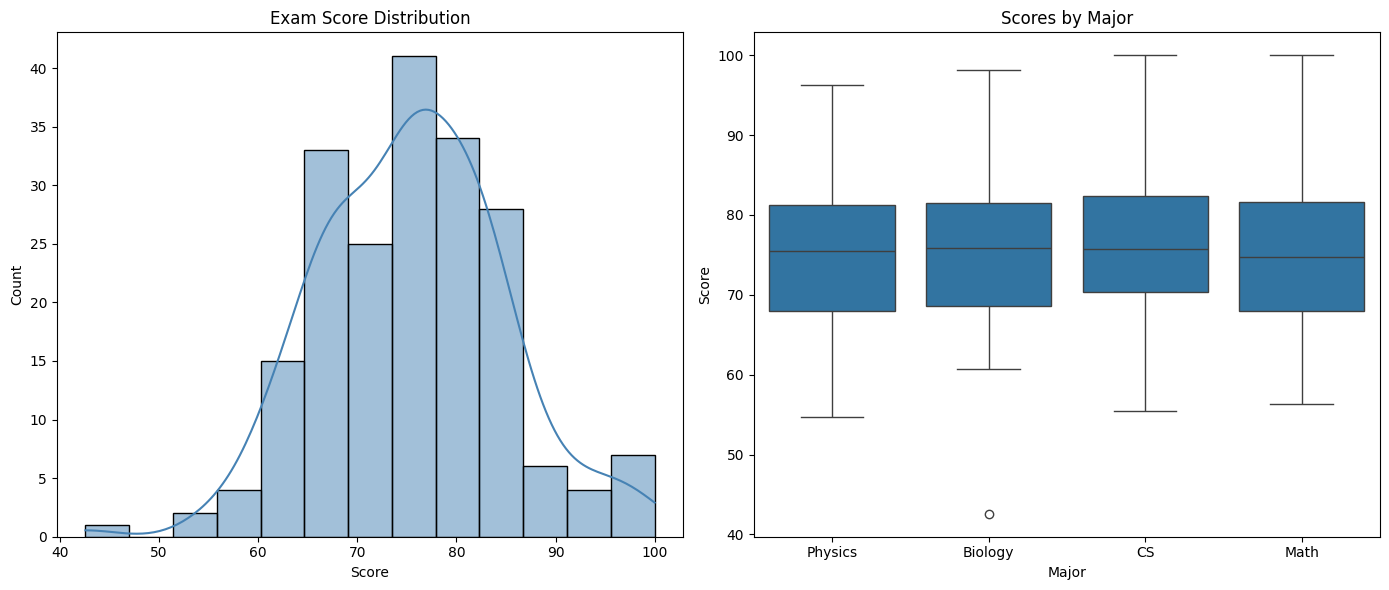

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# histogram 
sns.histplot(df['exam_score'], kde=True, ax=ax1, color='steelblue')
ax1.set_title('Exam Score Distribution')
ax1.set_xlabel('Score')
ax1.set_ylabel('Count')

# boxplot by major
sns.boxplot(data=df, x='major', y='exam_score', ax=ax2)
ax2.set_title('Scores by Major')
ax2.set_xlabel('Major')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

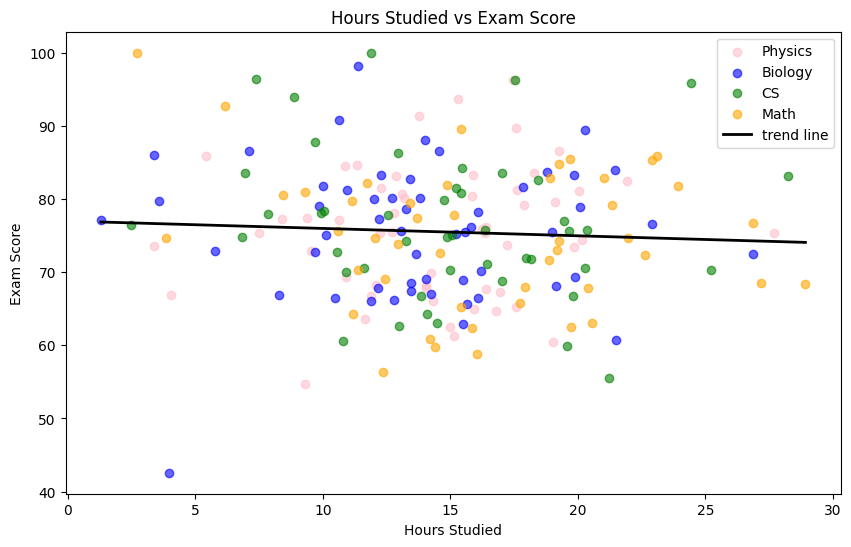

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

majors = df['major'].unique()
colors = ['pink', 'blue', 'green', 'orange']

for major, color in zip(majors, colors):
    subset = df[df['major'] == major]
    ax.scatter(subset['hours_studied'], subset['exam_score'],
               label=major, color=color, alpha=0.6)

# simple regression line
m, b = np.polyfit(df['hours_studied'], df['exam_score'], 1)
x_line = np.linspace(df['hours_studied'].min(), df['hours_studied'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2, label='trend line')

ax.set_title('Hours Studied vs Exam Score')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
ax.legend()
plt.show()

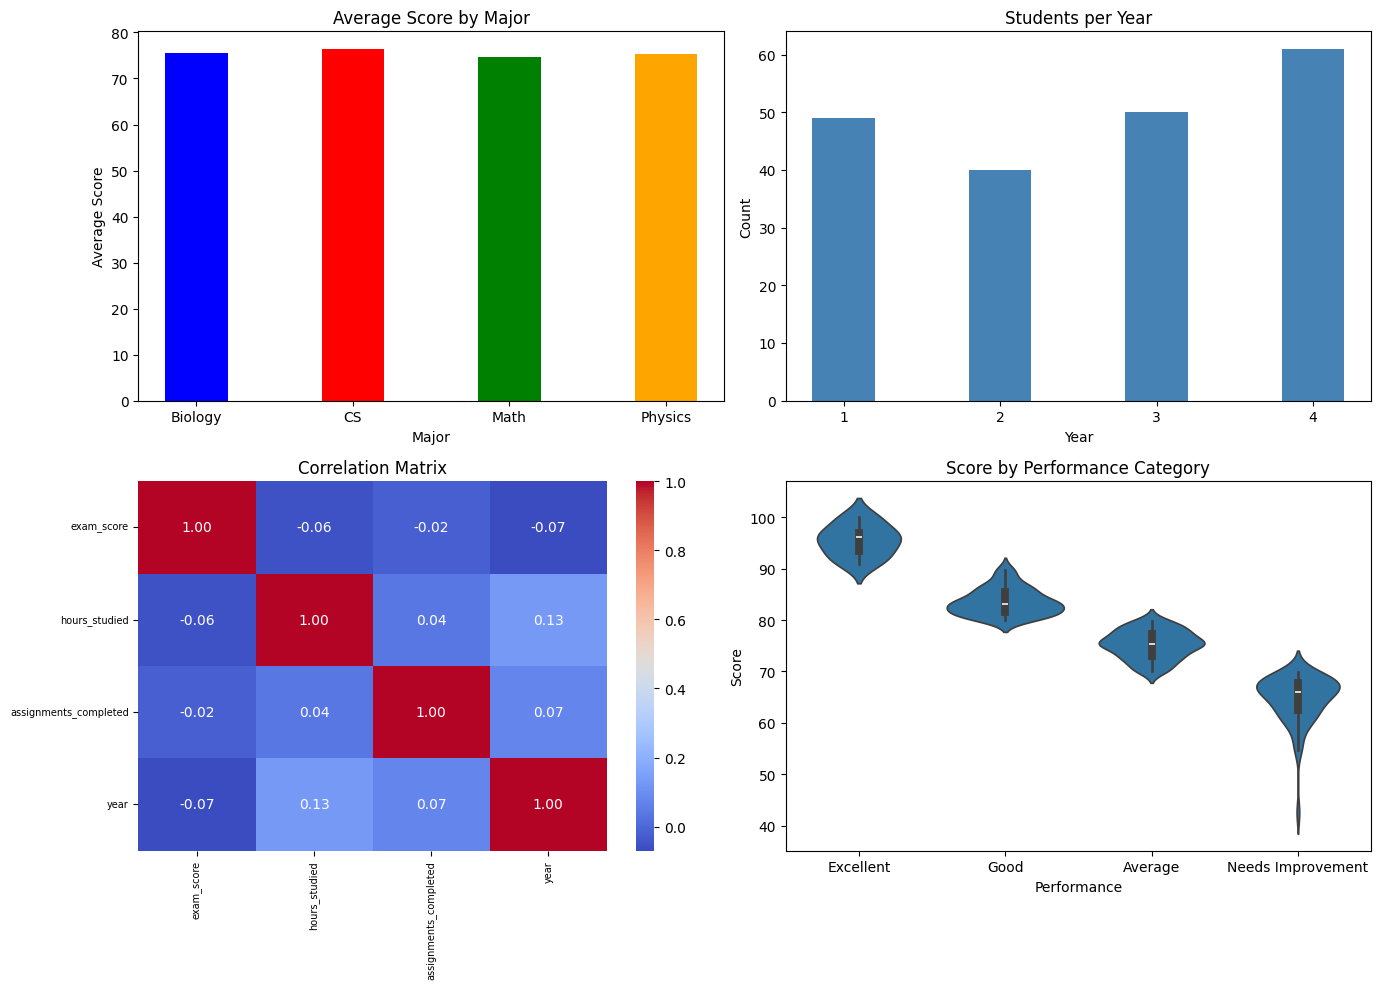

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# bar chart
major_avg = df.groupby('major')['exam_score'].mean()
axes[0, 0].bar(major_avg.index, major_avg.values, color=['blue', 'red', 'green', 'orange'], width=0.4)
axes[0, 0].set_title('Average Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# count by year
year_counts = df['year'].value_counts().sort_index()
axes[0, 1].bar(year_counts.index, year_counts.values, color='steelblue', width=0.4)
axes[0, 1].set_xticks([1, 2, 3, 4])
axes[0, 1].set_title('Students per Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# heatmap
corr = df[['exam_score', 'hours_studied', 'assignments_completed', 'year']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1, 0], fmt='.2f')
axes[1, 0].set_title('Correlation Matrix')
axes[1, 0].tick_params(axis='y', labelsize=7)
axes[1, 0].tick_params(axis='x', labelsize=7)

# violin plot
order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
sns.violinplot(data=df, x='performance', y='exam_score', order=order, ax=axes[1, 1])
axes[1, 1].set_title('Score by Performance Category')
axes[1, 1].set_xlabel('Performance')
axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

Integration Challenge

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

print("Dataset created!")
print(customers.head())

Dataset created!
   age        income  purchase_frequency  avg_purchase_value
0   56  92443.123940                   7           94.527456
1   69  70649.305211                   2          100.932279
2   46  19612.600681                   3           79.699876
3   32  40315.318543                   2          130.137787
4   60  75338.222984                   8          102.904845


In [26]:
# calculating the churn risk and CLV
max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

# creating the age groups
bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, include_lowest=True)

print("CLV and age groups added!")
print(customers.head())

CLV and age groups added!
   age        income  purchase_frequency  avg_purchase_value  churn_risk  \
0   56  92443.123940                   7           94.527456    0.416667   
1   69  70649.305211                   2          100.932279    0.833333   
2   46  19612.600681                   3           79.699876    0.750000   
3   32  40315.318543                   2          130.137787    0.833333   
4   60  75338.222984                   8          102.904845    0.333333   

           CLV age_group  
0   937.397271     51-70  
1   370.085023     51-70  
2   418.424348     36-50  
3   477.171887     26-35  
4  1097.651683     51-70  


In [27]:
# analysis for each age group
age_group_analysis = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)

print("Analysis by Age Group:")
print(age_group_analysis)

# Toping 10% customers by CLV
top_10 = customers[customers['CLV'] >= customers['CLV'].quantile(0.90)]
print(f"\nTop 10% customers: {len(top_10)} customers")
print(top_10[['age', 'income', 'purchase_frequency', 'CLV']].head(10))

Analysis by Age Group:
           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

Top 10% customers: 50 customers
    age        income  purchase_frequency          CLV
6    38  58876.388563                  10  1287.201143
9    40  48809.492879                  10  1286.000108
19   41  21282.756976                   8  1276.279663
24   38  53981.193911                   8  1283.421714
57   64  45956.146951                   7  1343.416638
60   25  66508.326980                   7  1408.591795
76   61  62482.396341                   7  1267.760075
79   53  32054.912570                  10  1270.066217
82   65  69502.394668                  10  1371.883208
86   40  58258.629086                   8  1355.1861

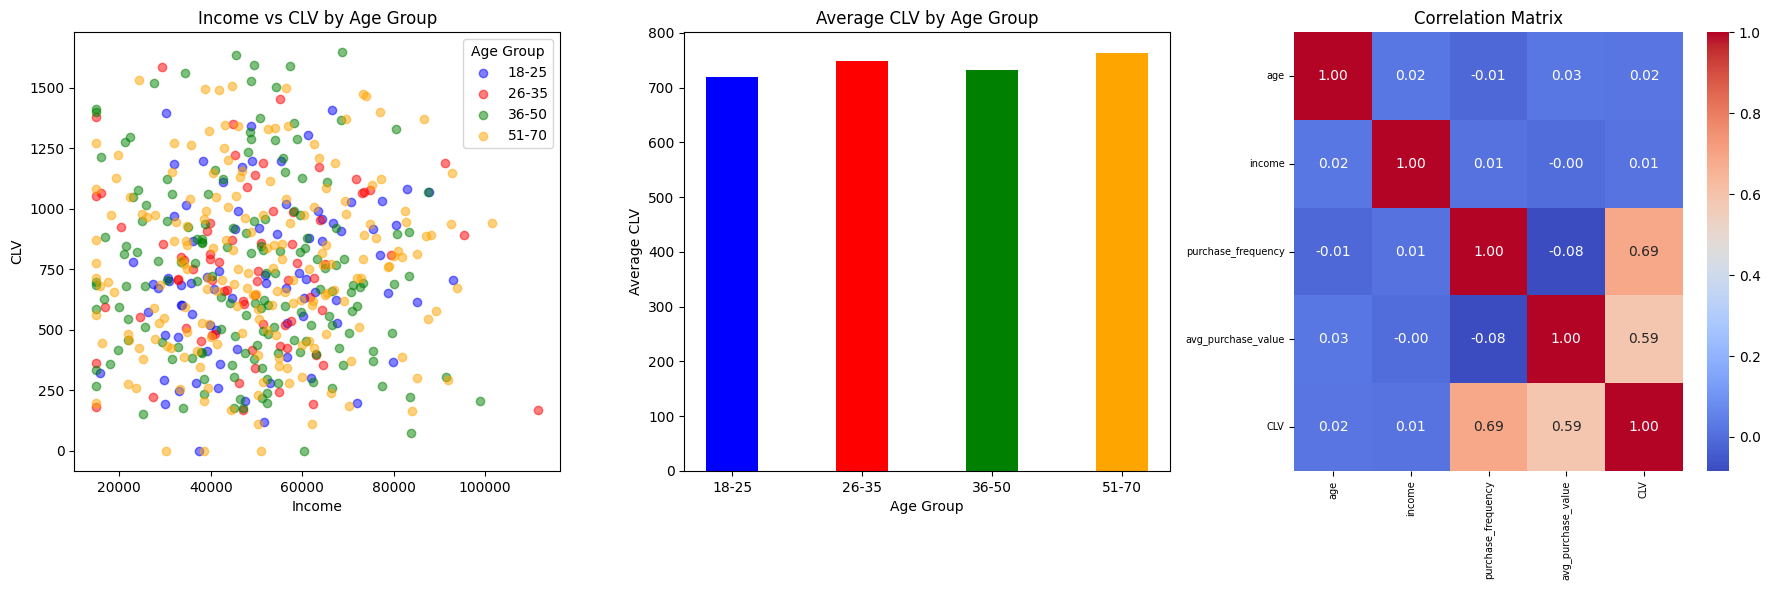

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. scatter plot income vs CLV colored by age group
colors = {'18-25': 'blue', '26-35': 'red', '36-50': 'green', '51-70': 'orange'}
for group, color in colors.items():
    subset = customers[customers['age_group'] == group]
    axes[0].scatter(subset['income'], subset['CLV'], label=group, color=color, alpha=0.5)
axes[0].set_title('Income vs CLV by Age Group')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('CLV')
axes[0].legend(title='Age Group')

# 2. bar chart average CLV by age group
avg_clv = customers.groupby('age_group')['CLV'].mean()
axes[1].bar(avg_clv.index, avg_clv.values, color=['blue', 'red', 'green', 'orange'], width=0.4)
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV')

# 3. correlation heatmap
corr = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[2], fmt='.2f')
axes[2].set_title('Correlation Matrix')
axes[2].tick_params(axis='x', labelsize=7)
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

## Key Findings and Recommendations
Looking at the customer data, younger customers 18-25 tend to have 
lower income but higher purchase frequency, which gives them a moderate CLV. 
Customers in the 36-50 age group generally have higher income and stable 

The correlation analysis shows that purchase frequency has the strongest 
impact on CLV compared to income or age. This means the company should 
focus on strategies that increase how often customers buy rather than 
targeting only high income customers.

For the top 10% of customers by CLV, the company should introduce a loyalty 
program to retain them. For younger customers, targeted promotions could 
help increase their purchase frequency and grow their long term value.